In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import numpy as np

# Evaluation Metrics and Subset Extraction Functions
Uncomment the feature extraction function you want to use.

In [1]:

from evaluation_metrics import get_classification_report, get_f1_score, get_auc_score, get_eer_score
from ResNet18 import extract_subsets_ResNet18
from ResNet50 import extract_subsets_ResNet50
from MobileNet import extract_subsets_MobileNet
from InceptionV3 import extract_subsets_InceptionV3
from EfficientNet import extract_subsets_EfficientNet

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/majaambrozic/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 57.3MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/majaambrozic/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 64.0MB/s]


Extract subsets for chosen feature extraction function.

In [2]:
# X_train, X_test, y_train, y_test = extract_subsets_ResNet18()
# X_train, X_test, y_train, y_test = extract_subsets_ResNet50()
# X_train, X_test, y_train, y_test = extract_subsets_MobileNet()
X_train, X_test, y_train, y_test = extract_subsets_InceptionV3()
# X_train, X_test, y_train, y_test = extract_subsets_EfficientNet()

## SIMPLE MODELS

Using libriaries like sklearn, xgboost, lightgbm and catboost.

# Linear regression

In [5]:
linearModel = LinearRegression()
linearModel.fit(X_train, y_train)

raw_predictions = linearModel.predict(X_test)
final_preds = [1 if p >= 0.5 else 0 for p in raw_predictions]

print("F1 Score: " + str(get_f1_score(y_test, final_preds)))
print("AUC Score: " + str(get_auc_score(y_test, raw_predictions)))
print("EER Score: " + str(get_eer_score(y_test, raw_predictions)))
print("Classification Report: \n" + str(get_classification_report(y_test, final_preds, digits=4)))


F1 Score: 0.5549738219895288
AUC Score: 0.5891
EER Score: 0.4200000000000005
Classification Report: 
              precision    recall  f1-score   support

           0     0.5688    0.6200    0.5933       100
           1     0.5824    0.5300    0.5550       100

    accuracy                         0.5750       200
   macro avg     0.5756    0.5750    0.5741       200
weighted avg     0.5756    0.5750    0.5741       200



# Logistic regression

In [6]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
probability_pred_clf = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_clf)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_clf)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred, digits=4)))

F1 Score: 0.5492227979274611
AUC Score: 0.5893999999999999
EER Score: 0.43000000000000393
Classification Report: 
              precision    recall  f1-score   support

           0     0.5607    0.6000    0.5797       100
           1     0.5699    0.5300    0.5492       100

    accuracy                         0.5650       200
   macro avg     0.5653    0.5650    0.5645       200
weighted avg     0.5653    0.5650    0.5645       200



# K-NN

In [7]:
knnModel = KNeighborsClassifier(n_neighbors=5)
knnModel.fit(X_train, y_train)
probability_pred_knn = knnModel.predict_proba(X_test)[:, 1]
pred_knn = knnModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_knn)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_knn)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_knn)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_knn, digits=4)))

F1 Score: 0.6009389671361502
AUC Score: 0.5741499999999999
EER Score: 0.4288235294117647
Classification Report: 
              precision    recall  f1-score   support

           0     0.5862    0.5100    0.5455       100
           1     0.5664    0.6400    0.6009       100

    accuracy                         0.5750       200
   macro avg     0.5763    0.5750    0.5732       200
weighted avg     0.5763    0.5750    0.5732       200



# Naive Bayes

In [8]:
nbModel = GaussianNB()
nbModel.fit(X_train, y_train)
probability_pred_nb = nbModel.predict_proba(X_test)[:, 1]
pred_nb = nbModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_nb)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_nb)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_nb)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_nb, digits=4)))

F1 Score: 0.5514018691588785
AUC Score: 0.5568000000000001
EER Score: 0.44554455445544555
Classification Report: 
              precision    recall  f1-score   support

           0     0.5233    0.4500    0.4839       100
           1     0.5175    0.5900    0.5514       100

    accuracy                         0.5200       200
   macro avg     0.5204    0.5200    0.5176       200
weighted avg     0.5204    0.5200    0.5176       200



# SVM

In [9]:
svmModel = SVC(kernel='rbf')
svmModel.fit(X_train, y_train)
probability_pred_svm = svmModel.decision_function(X_test)
pred_svm = svmModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_svm)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_svm)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_svm)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_svm, digits=4)))

F1 Score: 0.5803108808290155
AUC Score: 0.6005
EER Score: 0.43999999999999995
Classification Report: 
              precision    recall  f1-score   support

           0     0.5888    0.6300    0.6087       100
           1     0.6022    0.5600    0.5803       100

    accuracy                         0.5950       200
   macro avg     0.5955    0.5950    0.5945       200
weighted avg     0.5955    0.5950    0.5945       200



# Random forests

In [10]:
rfModel = RandomForestClassifier(n_estimators=100, random_state=42)
rfModel.fit(X_train, y_train)
probability_pred_rf = rfModel.predict_proba(X_test)[:, 1]
pred_rf = rfModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_rf)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_rf)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_rf)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_rf, digits=4)))

F1 Score: 0.5699481865284974
AUC Score: 0.6055500000000001
EER Score: 0.43
Classification Report: 
              precision    recall  f1-score   support

           0     0.5794    0.6200    0.5990       100
           1     0.5914    0.5500    0.5699       100

    accuracy                         0.5850       200
   macro avg     0.5854    0.5850    0.5845       200
weighted avg     0.5854    0.5850    0.5845       200



# Multilayer Perceptron (MLP)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50), 
    max_iter=500, 
    activation='relu', 
    solver='adam', 
    random_state=42,
    verbose=False # This lets you print the "loss" or not during training
)

mlp.fit(X_train_scaled, y_train)
probability_pred_mlp = mlp.predict_proba(X_test_scaled)[:, 1]
final_preds = mlp.predict(X_test_scaled)

print("F1 Score: " + str(get_f1_score(y_test, final_preds)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_mlp)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_mlp)))
print("Classification Report: \n" + str(get_classification_report(y_test, final_preds, digits=4)))

F1 Score: 0.5771144278606966
AUC Score: 0.5992
EER Score: 0.42999999999837757
Classification Report: 
              precision    recall  f1-score   support

           0     0.5758    0.5700    0.5729       100
           1     0.5743    0.5800    0.5771       100

    accuracy                         0.5750       200
   macro avg     0.5750    0.5750    0.5750       200
weighted avg     0.5750    0.5750    0.5750       200



# XGBoost

In [12]:
xgb_rounds = 100
xgbModel = XGBClassifier(
    n_estimators=xgb_rounds,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgbModel.fit(X_train, y_train, verbose=False)
probability_pred_xgb = xgbModel.predict_proba(X_test)[:, 1]
pred_xgb = xgbModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_xgb)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_xgb)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_xgb)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_xgb, digits=4)))

F1 Score: 0.5714285714285714
AUC Score: 0.5983
EER Score: 0.41999999999998155
Classification Report: 
              precision    recall  f1-score   support

           0     0.5769    0.6000    0.5882       100
           1     0.5833    0.5600    0.5714       100

    accuracy                         0.5800       200
   macro avg     0.5801    0.5800    0.5798       200
weighted avg     0.5801    0.5800    0.5798       200



# LightGBM

In [13]:
lgbmModel = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgbmModel.fit(X_train, y_train)
probability_pred_lgbm = lgbmModel.predict_proba(X_test)[:, 1]
pred_lgbm = lgbmModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_lgbm)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_lgbm)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_lgbm)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_lgbm, digits=4)))

F1 Score: 0.5578947368421052
AUC Score: 0.6287
EER Score: 0.4300000000003437
Classification Report: 
              precision    recall  f1-score   support

           0     0.5727    0.6300    0.6000       100
           1     0.5889    0.5300    0.5579       100

    accuracy                         0.5800       200
   macro avg     0.5808    0.5800    0.5789       200
weighted avg     0.5808    0.5800    0.5789       200



/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# CatBoost

In [14]:
catModel = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)
catModel.fit(X_train, y_train)
probability_pred_cat = catModel.predict_proba(X_test)[:, 1]
pred_cat = catModel.predict(X_test)

print("F1 Score: " + str(get_f1_score(y_test, pred_cat)))
print("AUC Score: " + str(get_auc_score(y_test, probability_pred_cat)))
print("EER Score: " + str(get_eer_score(y_test, probability_pred_cat)))
print("Classification Report: \n" + str(get_classification_report(y_test, pred_cat, digits=4)))

F1 Score: 0.5846153846153846
AUC Score: 0.6332
EER Score: 0.4200000000000014
Classification Report: 
              precision    recall  f1-score   support

           0     0.5905    0.6200    0.6049       100
           1     0.6000    0.5700    0.5846       100

    accuracy                         0.5950       200
   macro avg     0.5952    0.5950    0.5947       200
weighted avg     0.5952    0.5950    0.5947       200



# Comparison

Train every classifier on (X_train, y_train) and evaluate on (X_test, y_test).


In [15]:
# Returns a dict mapping classifier name → {f1, auc, eer}.
def run_classifiers(X_train, X_test, y_train, y_test):
    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_train)
    X_te_s   = scaler.transform(X_test)

    classifiers = [
        ("Linear Regression",   LinearRegression(), False),
        ("Logistic Regression", LogisticRegression(max_iter=2000), False),
        ("K-NN",                KNeighborsClassifier(n_neighbors=5), False),
        ("Naive Bayes",         GaussianNB(), False),
        ("SVM",                 SVC(kernel="rbf"), False),
        ("Random Forest",       RandomForestClassifier(n_estimators=100, random_state=42), False),
        ("MLP",                 MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500,
                                              activation="relu", solver="adam",
                                              random_state=42, verbose=False), True),
        ("XGBoost",             XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05,
                                              subsample=0.8, colsample_bytree=0.8,
                                              eval_metric="logloss", random_state=42,
                                              verbosity=0), False),
        ("LightGBM",            LGBMClassifier(n_estimators=100, learning_rate=0.05,
                                               num_leaves=31, random_state=42, verbose=-1), False),
        ("CatBoost",            CatBoostClassifier(iterations=100, learning_rate=0.05,
                                                   depth=6, random_seed=42, verbose=0), False),
    ]

    results = {}
    for name, model, use_scaled in classifiers:
        Xtr = X_tr_s if use_scaled else X_train
        Xte = X_te_s if use_scaled else X_test

        model.fit(Xtr, y_train)

        if isinstance(model, LinearRegression):
            raw   = model.predict(Xte)
            probs = raw
            preds = (raw >= 0.5).astype(int)
        elif isinstance(model, SVC):
            probs = model.decision_function(Xte)
            preds = model.predict(Xte)
        else:
            probs = model.predict_proba(Xte)[:, 1]
            preds = model.predict(Xte)

        results[name] = {
            "f1":  get_f1_score(y_test, preds),
            "auc": get_auc_score(y_test, probs),
            "eer": get_eer_score(y_test, probs),
        }
        print(f"  {name:<22} F1={results[name]['f1']:.4f}  "
              f"AUC={results[name]['auc']:.4f}  EER={results[name]['eer']:.4f}")

    return results


BACKBONES = {
    "ResNet18":     extract_subsets_ResNet18,
    "ResNet50":     extract_subsets_ResNet50,
    "MobileNet":    extract_subsets_MobileNet,
    "InceptionV3":  extract_subsets_InceptionV3,
    "EfficientNet": extract_subsets_EfficientNet,
}

# Run all classifiers on all backbones and store results in a dict.
all_results = {}
for backbone, extractor in BACKBONES.items():
    print(f"\n{'='*60}\nBackbone: {backbone}\n{'='*60}")
    X_train, X_test, y_train, y_test = extractor()
    all_results[backbone] = run_classifiers(X_train, X_test, y_train, y_test)


Backbone: ResNet18
  Linear Regression      F1=0.5131  AUC=0.5683  EER=0.4600
  Logistic Regression    F1=0.5744  AUC=0.6137  EER=0.4200
  K-NN                   F1=0.5871  AUC=0.6053  EER=0.4157
  Naive Bayes            F1=0.6087  AUC=0.6007  EER=0.4200
  SVM                    F1=0.5789  AUC=0.6614  EER=0.4100
  Random Forest          F1=0.5684  AUC=0.6149  EER=0.4133
  MLP                    F1=0.5644  AUC=0.6174  EER=0.4400
  XGBoost                F1=0.6186  AUC=0.6711  EER=0.3600


/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM               F1=0.5728  AUC=0.6546  EER=0.4300
  CatBoost               F1=0.5773  AUC=0.6433  EER=0.4100

Backbone: ResNet50
  Linear Regression      F1=0.5876  AUC=0.6743  EER=0.4100
  Logistic Regression    F1=0.6806  AUC=0.7590  EER=0.2800
  K-NN                   F1=0.6267  AUC=0.6252  EER=0.4167
  Naive Bayes            F1=0.6213  AUC=0.5604  EER=0.4538
  SVM                    F1=0.6702  AUC=0.7548  EER=0.3200
  Random Forest          F1=0.6832  AUC=0.7212  EER=0.3260
  MLP                    F1=0.6872  AUC=0.7464  EER=0.3100
  XGBoost                F1=0.7019  AUC=0.7690  EER=0.3200


/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM               F1=0.7053  AUC=0.7590  EER=0.3200
  CatBoost               F1=0.6923  AUC=0.7349  EER=0.3300

Backbone: MobileNet
  Linear Regression      F1=0.5951  AUC=0.6118  EER=0.4200
  Logistic Regression    F1=0.6364  AUC=0.6902  EER=0.3500
  K-NN                   F1=0.6330  AUC=0.6111  EER=0.4129
  Naive Bayes            F1=0.6261  AUC=0.5766  EER=0.4309
  SVM                    F1=0.6383  AUC=0.7118  EER=0.3400
  Random Forest          F1=0.6489  AUC=0.7160  EER=0.3471
  MLP                    F1=0.5825  AUC=0.6424  EER=0.4200
  XGBoost                F1=0.6599  AUC=0.7198  EER=0.3500


...

  LightGBM               F1=0.6863  AUC=0.7423  EER=0.3100
  CatBoost               F1=0.6633  AUC=0.7181  EER=0.3300

Backbone: InceptionV3
  Linear Regression      F1=0.5550  AUC=0.5891  EER=0.4200
  Logistic Regression    F1=0.5492  AUC=0.5894  EER=0.4300
  K-NN                   F1=0.6009  AUC=0.5741  EER=0.4288
  Naive Bayes            F1=0.5514  AUC=0.5568  EER=0.4455
  SVM                    F1=0.5803  AUC=0.6005  EER=0.4400
  Random Forest          F1=0.5699  AUC=0.6056  EER=0.4300
  MLP                    F1=0.5771  AUC=0.5992  EER=0.4300
  XGBoost                F1=0.5714  AUC=0.5983  EER=0.4200


/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM               F1=0.5579  AUC=0.6287  EER=0.4300
  CatBoost               F1=0.5846  AUC=0.6332  EER=0.4200

Backbone: EfficientNet
  Linear Regression      F1=0.5436  AUC=0.5992  EER=0.4500
  Logistic Regression    F1=0.6154  AUC=0.6654  EER=0.3800
  K-NN                   F1=0.5856  AUC=0.5740  EER=0.4623
  Naive Bayes            F1=0.5991  AUC=0.5882  EER=0.4190
  SVM                    F1=0.6000  AUC=0.6806  EER=0.3700
  Random Forest          F1=0.6300  AUC=0.6579  EER=0.3700
  MLP                    F1=0.6030  AUC=0.6630  EER=0.3900
  XGBoost                F1=0.6250  AUC=0.7069  EER=0.3600


/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/majaambrozic/Documents/DRL/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM               F1=0.6138  AUC=0.6629  EER=0.3900
  CatBoost               F1=0.6170  AUC=0.6873  EER=0.3400


/var/folders/49/0xgk_jsx7zqfkzskz539mjm40000gn/T/ipykernel_44908/709328535.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bg = plt.cm.get_cmap(cmap)(val)


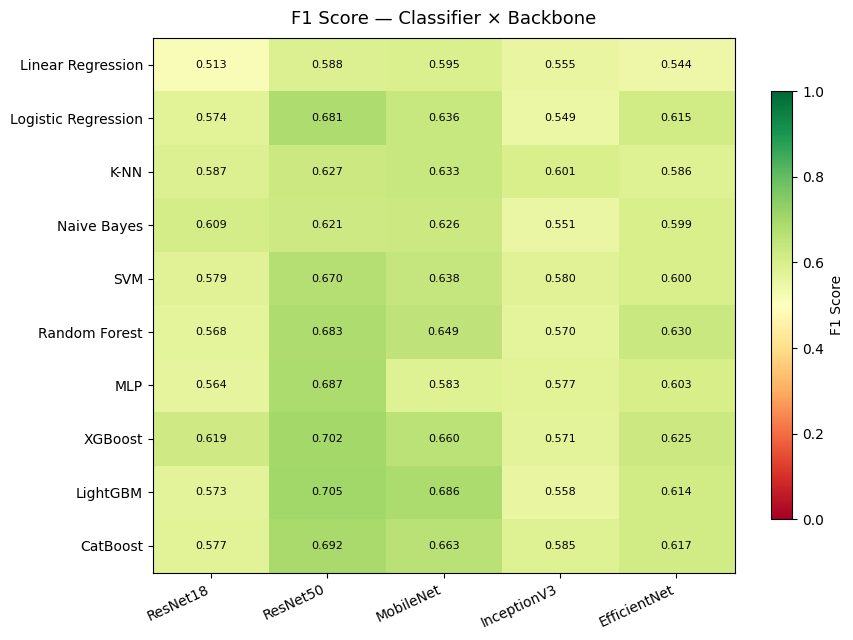

/var/folders/49/0xgk_jsx7zqfkzskz539mjm40000gn/T/ipykernel_44908/709328535.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bg = plt.cm.get_cmap(cmap)(val)


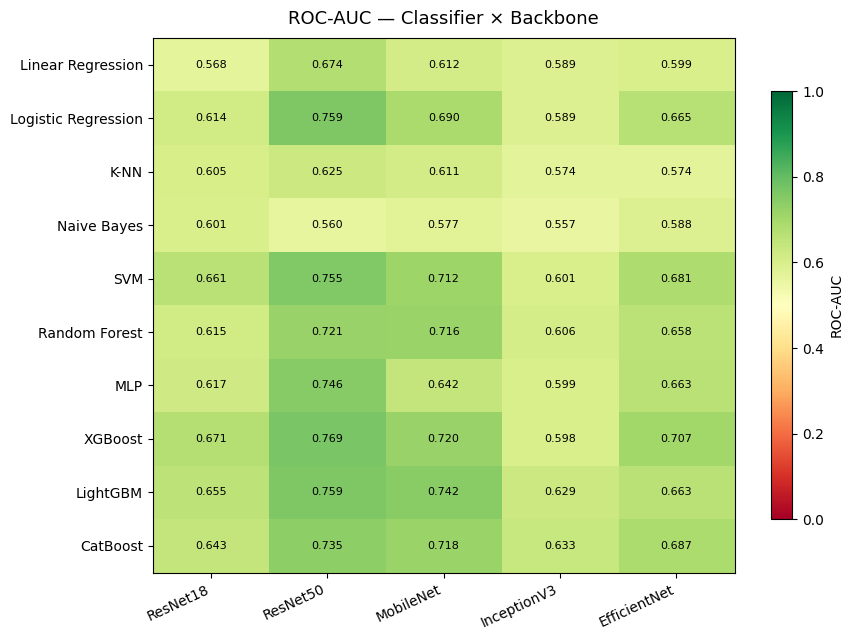

/var/folders/49/0xgk_jsx7zqfkzskz539mjm40000gn/T/ipykernel_44908/709328535.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bg = plt.cm.get_cmap(cmap)(val)


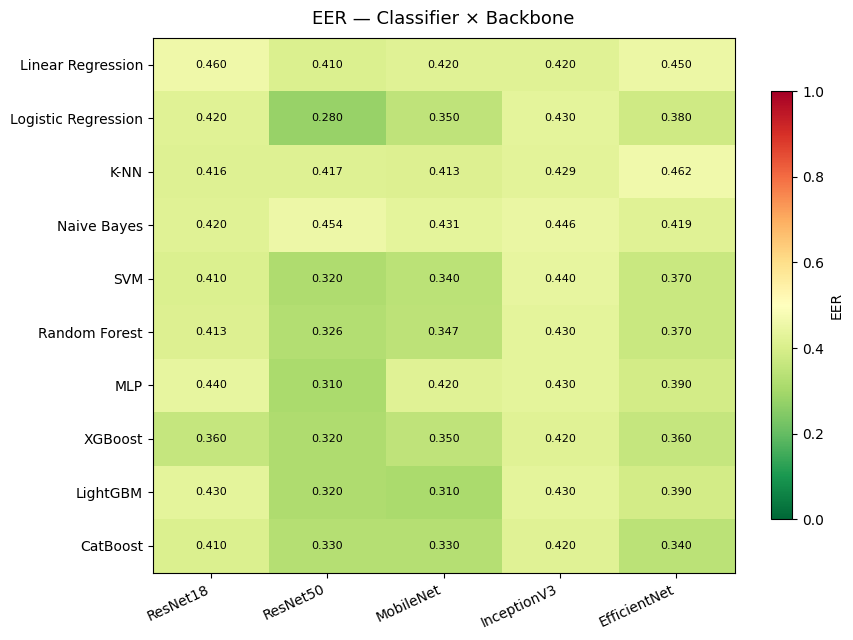

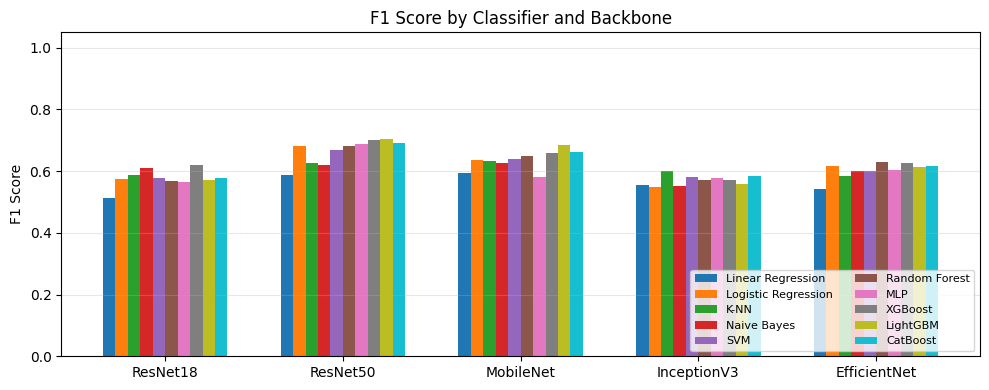

In [16]:
backbones   = list(all_results.keys())
classifiers = list(next(iter(all_results.values())).keys())

# Per-metric heatmaps (classifiers × backbones).
for metric, title, cmap in [
    ("f1",  "F1 Score",  "RdYlGn"),
    ("auc", "ROC-AUC",  "RdYlGn"),
    ("eer", "EER",       "RdYlGn_r"),   # reversed: lower EER is better
]:
    matrix = np.array([
        [all_results[b][c][metric] for b in backbones]
        for c in classifiers
    ])

    fig, ax = plt.subplots(figsize=(len(backbones) * 1.6 + 1, len(classifiers) * 0.55 + 1))
    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8, label=title)

    ax.set_xticks(range(len(backbones)))
    ax.set_xticklabels(backbones, rotation=25, ha="right", fontsize=10)
    ax.set_yticks(range(len(classifiers)))
    ax.set_yticklabels(classifiers, fontsize=10)
    ax.set_title(f"{title} — Classifier × Backbone", fontsize=13, pad=10)

    for i in range(len(classifiers)):
        for j in range(len(backbones)):
            val = matrix[i, j]
            # pick text colour for contrast
            bg = plt.cm.get_cmap(cmap)(val)
            lum = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color="black" if lum > 0.45 else "white")

    plt.tight_layout()
    plt.savefig(f"./results/simple_models_{metric}_heatmap.png", dpi=300)
    plt.show()

# Best classifier per backbone (F1 score) as grouped bar chart.
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10.colors
x = np.arange(len(backbones))
width = 0.7 / len(classifiers)

for i, clf in enumerate(classifiers):
    vals = [all_results[b][clf]["f1"] for b in backbones]
    ax.bar(x + (i - len(classifiers) / 2 + 0.5) * width, vals,
           width=width, color=colors[i % len(colors)], label=clf)

ax.set_xticks(x)
ax.set_xticklabels(backbones, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Classifier and Backbone")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./results/simple_models_f1_heatmap.png", dpi=300)
plt.show()

# Two-Branch ResNet18

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from TwoBranchResNet18 import (
    build_default_two_branch_setup,
    fit_two_stage_model,
    evaluate,
)
import torch.nn as nn

# Construct the model and data loaders for the two-branch ResNet18 setup
# Takes original and blurred images as inputs and trains in two stages (first on blurred, then on original).
model, train_loader, val_loader = build_default_two_branch_setup(
    image_size=224,
    blur_radius=2.0,
    batch_size=32,
    test_size=0.2,
    pretrained=True,
)

# Train the model in two stages: first on blurred images, then on original images, with different learning rates and epochs for each stage.
history = fit_two_stage_model(
    model,
    train_loader,
    val_loader,
    phase1_epochs=3,
    phase2_epochs=5,
    phase1_lr=1e-3,
    phase2_lr=1e-4,
)

# Evaluation
criterion = nn.CrossEntropyLoss()
val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion)

print("F1 Score: ", f1_score(y_true, y_pred))
print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)
print("Confusion Matrix: \n" + str(confusion_matrix(y_true, y_pred)))
print("Classification Report: \n" + str(classification_report(y_true, y_pred, digits=4)))

Phase 2:   0%|          | 0/5 [00:08<?, ?it/s]


KeyboardInterrupt: 